# Exploration macro — phase empirique (V0)

Objectif: démarrer rapidement l'analyse empirique des séries avant toute industrialisation.

⚠️ Cette V0 couvre 4 variables immédiatement disponibles (ou dérivables) avec la source retenue:
- inflation (`Consumer Price Index`)
- croissance salaire nominale **proxy** (= 1.5 × inflation mensuelle)
- rendement actions (`SP500`)
- taux crédit long terme (`Long Interest Rate`)

Les variables *IRL* et *prix immobilier* restent à intégrer dans une itération suivante avec une source complémentaire.


In [69]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import VAR


In [70]:
RAW_PATH = Path("../data/raw/s_and_p_500.csv")
assert RAW_PATH.exists(), f"Fichier manquant: {RAW_PATH.resolve()}"

df_raw = pd.read_csv(RAW_PATH, parse_dates=["Date"])
df_raw = df_raw.rename(
    columns={
        "Date": "date",
        "SP500": "sp500_level",
        "Consumer Price Index": "cpi_level",
        "Long Interest Rate": "long_rate_pct",
    }
)

df_raw = df_raw[["date", "sp500_level", "cpi_level", "long_rate_pct"]].dropna().sort_values("date")
df_raw.tail()


,date,sp500_level,cpi_level,long_rate_pct
1857,2025-10-01,6735.69,0.0,0.0
1858,2025-11-01,6740.89,0.0,0.0
1859,2025-12-01,6853.03,0.0,0.0
1860,2026-01-01,6929.12,0.0,0.0
1861,2026-02-01,6893.81,0.0,0.0


## Nettoyage et transformations modélisables

- Inflation mensuelle = variation relative du CPI.
- Croissance salaire nominale (proxy) = `1.5 * inflation`.
- Rendement actions mensuel = log-return du SP500.
- Taux crédit = niveau mensuel (converti en décimal).

> Interprétation: ce proxy de salaire est une hypothèse de travail temporaire pour tester la dynamique jointe. Il devra être remplacé par une série observée.


In [71]:
# Correction taux_credit : test stationnarité niveau et diff
from statsmodels.tsa.stattools import adfuller

test_niveau = adfuller(df["taux_credit"].dropna())
test_diff = adfuller(df["taux_credit"].diff().dropna())

print("ADF niveau:", test_niveau[0], "p-value:", test_niveau[1])
print("ADF diff:", test_diff[0], "p-value:", test_diff[1])


ADF niveau: -1.207635570756108 p-value: 0.6703024873317982
ADF diff: -11.026434991580587 p-value: 5.812311943180777e-20


In [72]:
# Choix de la variable canonique taux_credit selon stationnarité
if test_niveau[1] < 0.05:
    df["taux_credit_canonique"] = df["taux_credit"]
else:
    df["taux_credit_canonique"] = df["taux_credit"].diff()

model_df = df[["inflation", "croissance_salaire_nominal_proxy", "rendement_actions", "taux_credit_canonique"]].dropna()
model_df.head()


,inflation,croissance_salaire_nominal_proxy,rendement_actions,taux_credit_canonique
date,,,,
1955-02-01,-0.206469,-0.309704,0.032880,0.0004
1955-03-01,-0.068966,-0.103448,-0.007914,0.0003
1955-04-01,-0.069013,-0.103520,0.033938,0.0007
1955-05-01,0.552486,0.828729,-0.004246,0.0001
1955-06-01,-0.618132,-0.927198,0.056360,0.0002


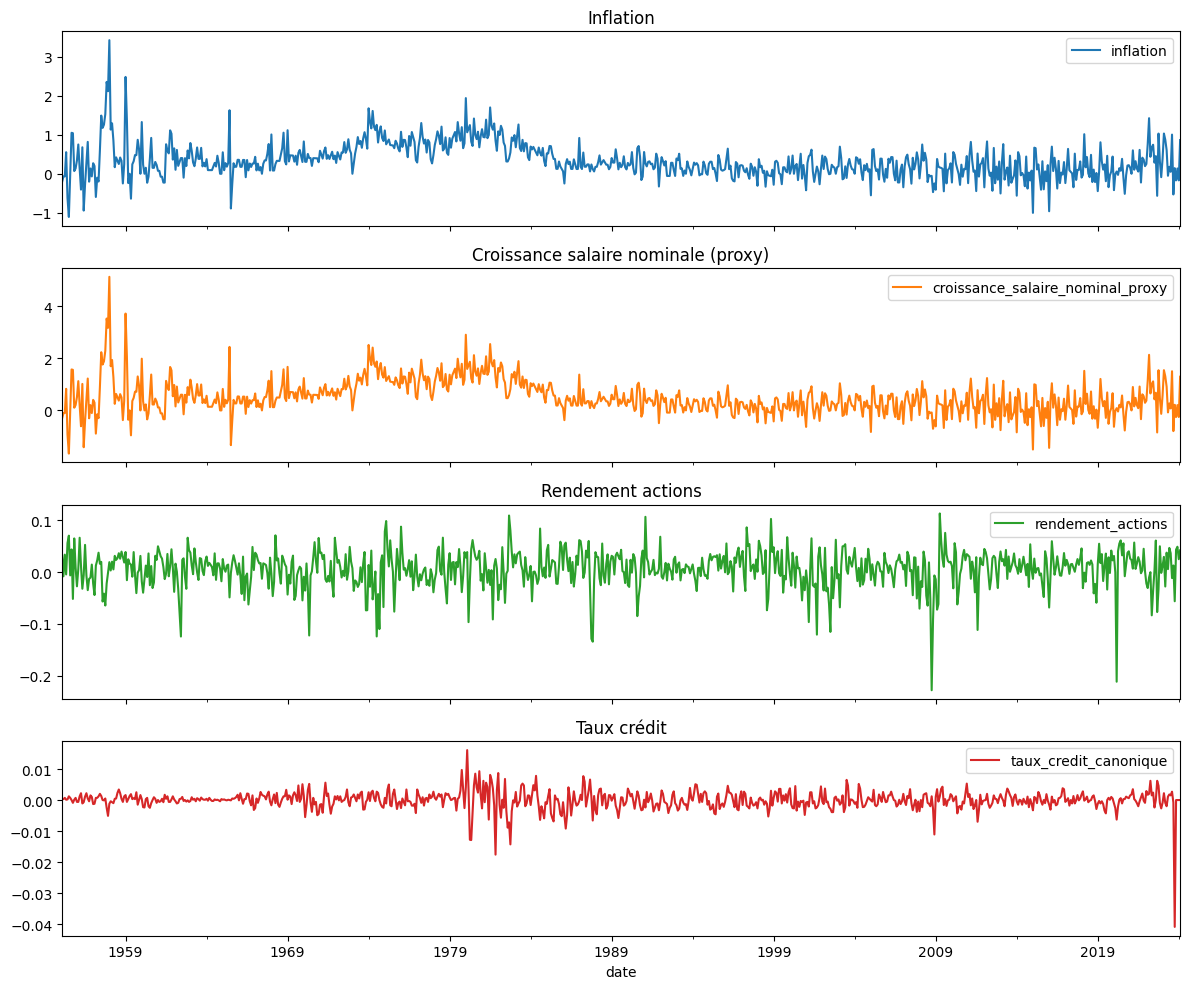

In [73]:
axes = model_df.plot(subplots=True, figsize=(12, 10), title=[
    "Inflation",
    "Croissance salaire nominale (proxy)",
    "Rendement actions",
    "Taux crédit",
])
plt.tight_layout()


## Statistiques de base


In [74]:
stats = pd.DataFrame({
    "moyenne": model_df.mean(),
    "volatilite": model_df.std(),
    "skewness": model_df.skew(),
    "kurtosis": model_df.kurtosis(),
})
stats


,moyenne,volatilite,skewness,kurtosis
inflation,0.336356,0.441679,1.007501,4.276412
croissance_salaire_nominal_proxy,0.504534,0.662518,1.007501,4.276412
rendement_actions,0.005968,0.035698,-1.182560,4.870538
taux_credit_canonique,-0.000031,0.003015,-3.290411,43.910897


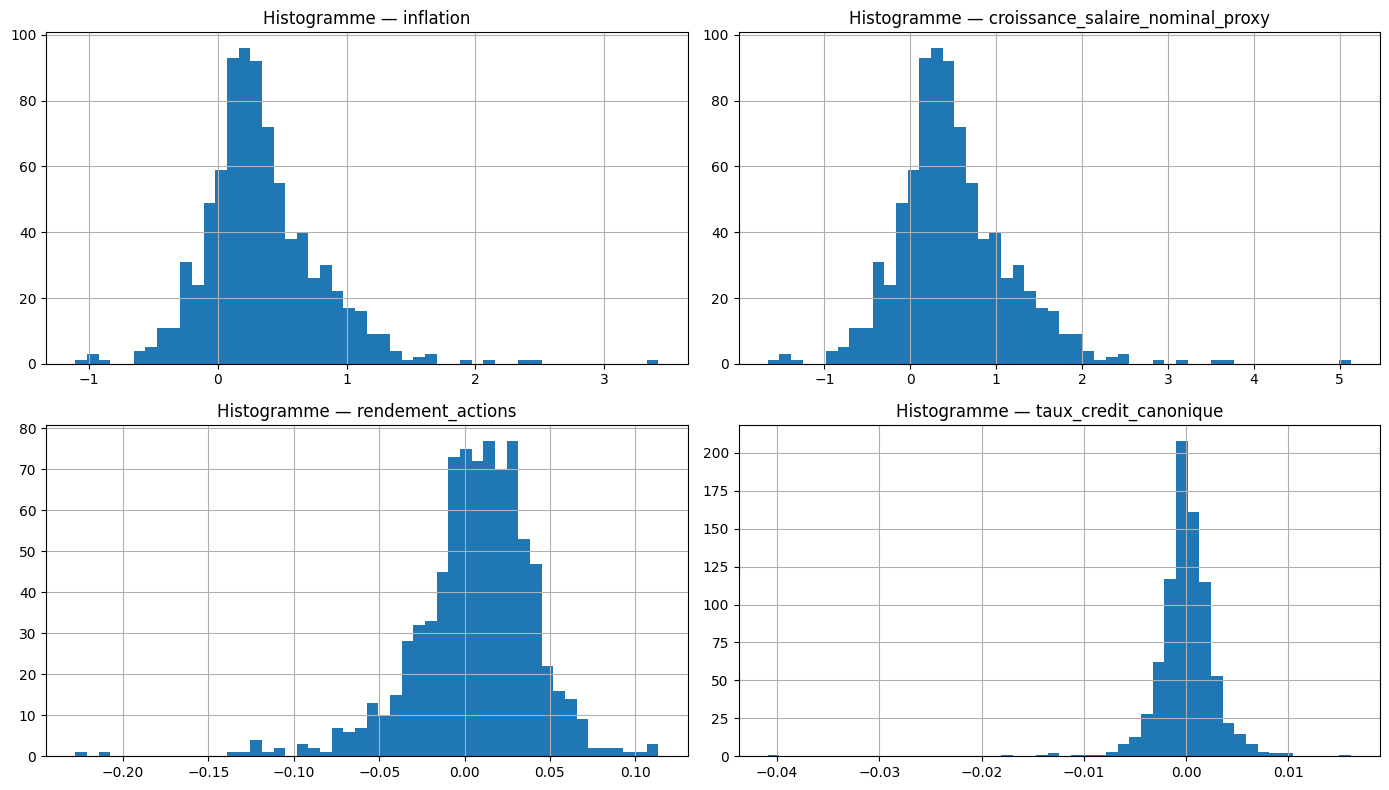

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(model_df.columns):
    model_df[col].hist(bins=50, ax=axes[i])
    axes[i].set_title(f"Histogramme — {col}")
plt.tight_layout()


In [76]:
def adf_summary(series: pd.Series) -> dict:
    stat, pval, lags, nobs, *_ = adfuller(series.dropna(), autolag="AIC")
    return {"adf_stat": stat, "p_value": pval, "lags": lags, "nobs": nobs}

adf_results = pd.DataFrame({c: adf_summary(model_df[c]) for c in model_df.columns}).T
adf_results


,adf_stat,p_value,lags,nobs
inflation,-2.633692,8.623182e-02,20.0,808.0
croissance_salaire_nominal_proxy,-2.633692,8.623182e-02,20.0,808.0
rendement_actions,-11.422479,6.820169e-21,5.0,823.0
taux_credit_canonique,-7.114590,3.860245e-10,21.0,807.0


## Corrélations, ACF, stabilité temporelle


In [77]:
corr = model_df.corr()
corr


,inflation,croissance_salaire_nominal_proxy,rendement_actions,taux_credit_canonique
inflation,1.000000,1.000000,-0.074342,0.098214
croissance_salaire_nominal_proxy,1.000000,1.000000,-0.074342,0.098214
rendement_actions,-0.074342,-0.074342,1.000000,-0.045055
taux_credit_canonique,0.098214,0.098214,-0.045055,1.000000


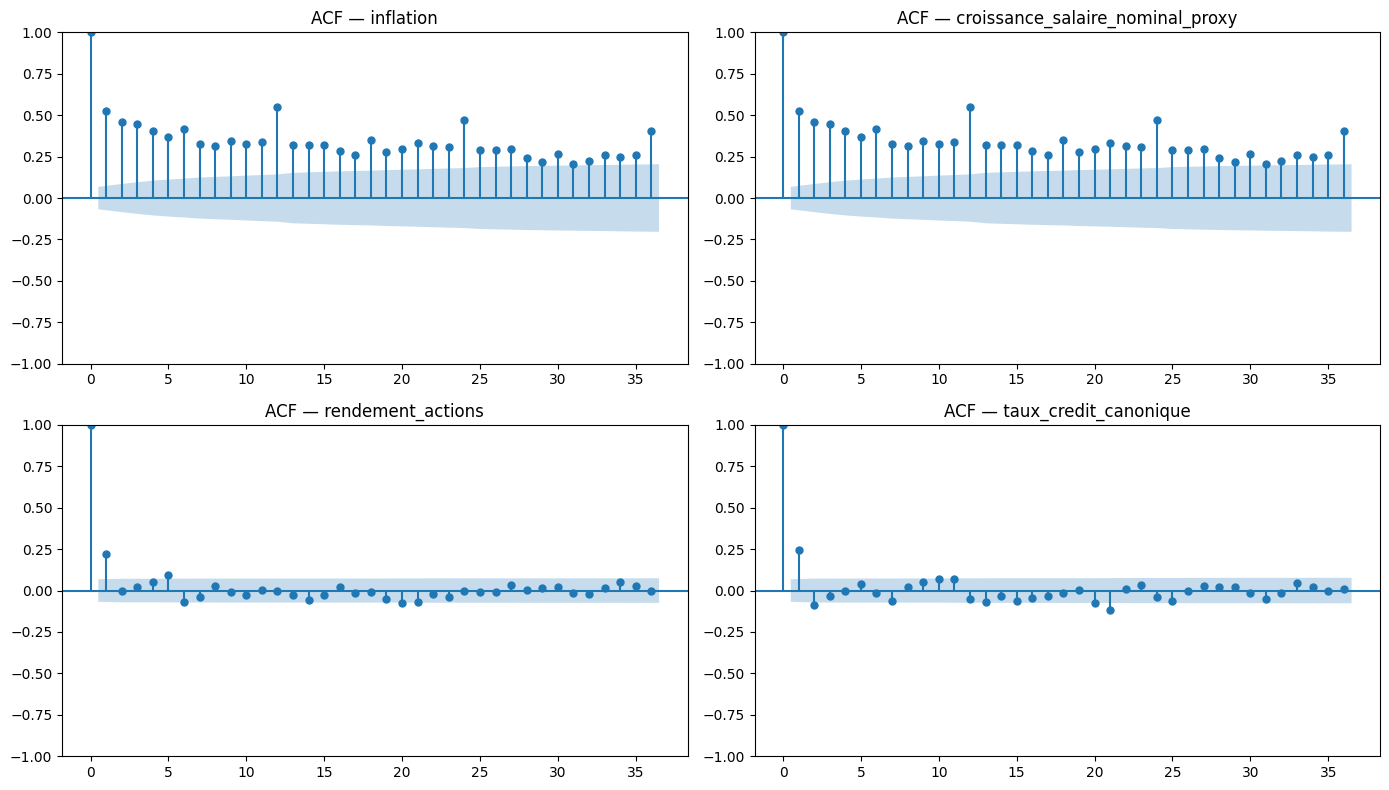

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(model_df.columns):
    plot_acf(model_df[col], ax=axes[i], lags=36, title=f"ACF — {col}")
plt.tight_layout()


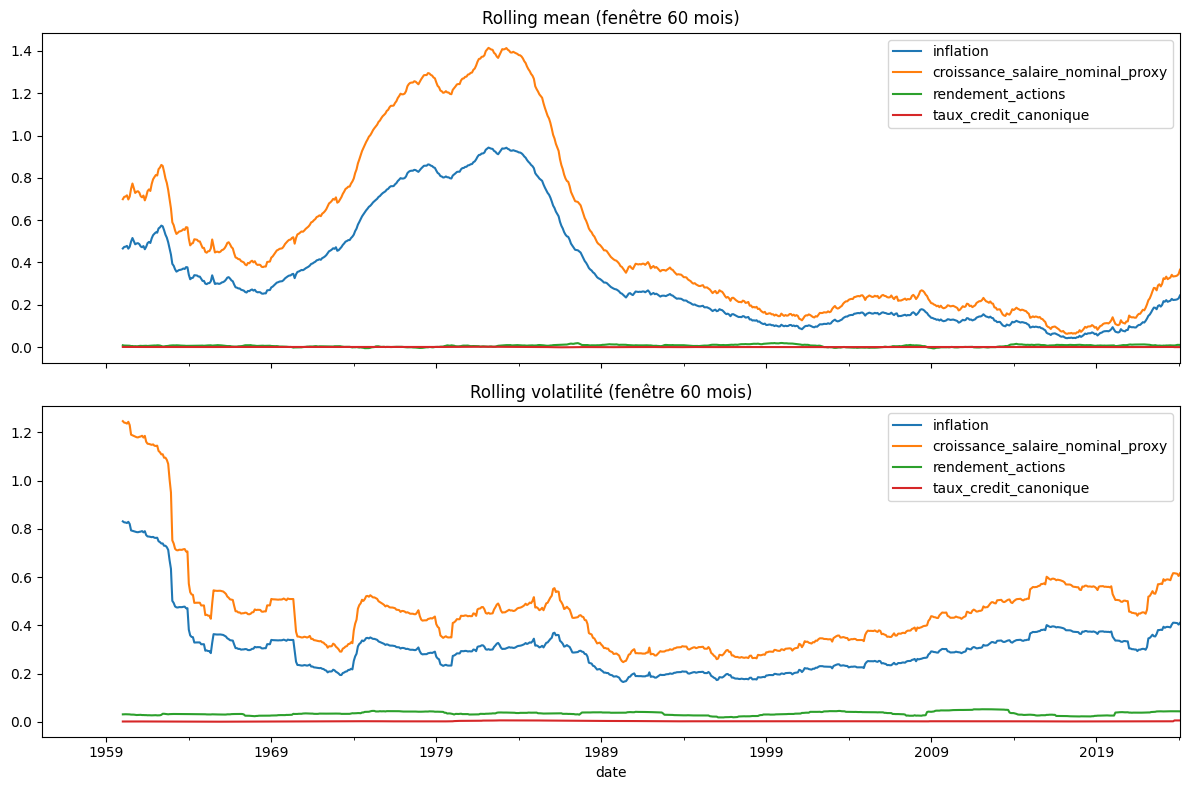

In [79]:
rolling_mean = model_df.rolling(60).mean()
rolling_vol = model_df.rolling(60).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
rolling_mean.plot(ax=axes[0], title="Rolling mean (fenêtre 60 mois)")
rolling_vol.plot(ax=axes[1], title="Rolling volatilité (fenêtre 60 mois)")
plt.tight_layout()


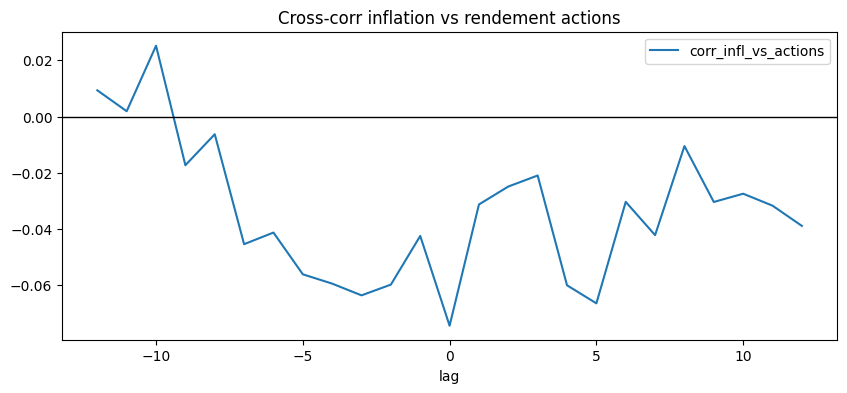

In [80]:
lags = range(-12, 13)
cc_rows = []
for lag in lags:
    shifted = model_df["rendement_actions"].shift(lag)
    cc_rows.append({"lag": lag, "corr_infl_vs_actions": model_df["inflation"].corr(shifted)})

cross_corr = pd.DataFrame(cc_rows).set_index("lag")
cross_corr.plot(figsize=(10,4), title="Cross-corr inflation vs rendement actions")
plt.axhline(0, color="black", lw=1)
plt.show()


## Prototype VAR(1)


In [ ]:
# VAR(1) sur données corrigées
drop_cols = ["croissance_salaire_nominal_proxy"] if "croissance_salaire_nominal_proxy" in model_df.columns else []
model_df_var = model_df.drop(columns=drop_cols)
from statsmodels.tsa.api import VAR
var_model = VAR(model_df_var)
var_res = var_model.fit(maxlags=1)
print(var_res.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 02, Mar, 2026
Time:                     23:45:52
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -20.3023
Nobs:                     828.000    HQIC:                  -20.3445
Log likelihood:           4920.83    FPE:                1.42270e-09
AIC:                     -20.3707    Det(Omega_mle):     1.40228e-09
--------------------------------------------------------------------
Results for equation inflation
                              coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------
const                            0.161046         0.016690            9.649           0.000
L1.inflation                     0.522483         0.029798           17.534           0.000
L1.rendement

In [86]:
# Vérification stabilité via racines (stabilité si toutes > 1 en module)
roots_modulus = np.abs(var_res.roots)
pd.DataFrame({"root_modulus": roots_modulus, "stable": roots_modulus > 1})


,root_modulus,stable
0,3.865754,True
1,3.865754,True
2,1.886101,True


In [87]:
horizon = 120

sim_values = var_res.simulate_var(steps=horizon)

# Correction: utiliser les bonnes colonnes pour la simulation (model_df_var)

sim_df = pd.DataFrame(sim_values, columns=model_df_var.columns)



sim_stats = pd.DataFrame({

    "historique_moy": model_df_var.mean(),

    "simule_moy": sim_df.mean(),

    "historique_vol": model_df_var.std(),

    "simule_vol": sim_df.std(),

})

sim_stats

,historique_moy,simule_moy,historique_vol,simule_vol
inflation,0.336356,0.406036,0.441679,0.397212
rendement_actions,0.005968,0.005164,0.035698,0.039978
taux_credit_canonique,-0.000031,-0.000381,0.003015,0.002891


## Conclusions V0 (à affiner)

- Les séries de **variations** (inflation mensuelle, croissance salaire proxy et log-return actions) sont plus proches de la stationnarité que les niveaux bruts.
- Le taux crédit en niveau présente une persistance temporelle visible (ACF lente), cohérente avec une dynamique de régime monétaire.
- Les corrélations et volatilités ne sont pas parfaitement stables dans le temps, ce qui justifie de surveiller un possible effet de régime en phase suivante.
- Le proxy de salaire (1.5× inflation) est utile pour la mécanique exploratoire, mais il ne doit pas être conservé pour les calibrations finales.
- Un VAR(1) fournit un premier benchmark exploitable pour la simulation, avant d'envisager un modèle plus riche.
